In [27]:
import torch
from torch import nn
import numpy as np
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,Subset
from torch.nn import functional as F

1. Metodo per creare il bit pattern: viene convertito la variabile num in un numero binario tramite la funzione bin() e tramite zfill(9) possiamo riempire di zeri il numero binario per avere 9 bit. Dopodichè viene creato un array numpy composto dai bit del numero binario, convertiti in float e creato il tensore

In [28]:
def create_kernel(num):
  binary_num = bin(num)[2:].zfill(9)
  np_array = np.array([float(bit) for bit in binary_num], dtype=np.float32)
  kernel = torch.from_numpy(np_array.reshape(3, 3))
  kernel[kernel==0.0]=-1.0
  return kernel

kernel = create_kernel(3)
print(kernel)

tensor([[-1., -1., -1.],
        [-1., -1., -1.],
        [-1.,  1.,  1.]])


2. Metodo per ottenere la convoluzione: vengono creati tutti i bit pattern possibili (kernels) e aggiunta una dimensione (tramite unsqueeze(1)) per essere dato in input alla rete convolutiva. Il metodo restituisce la rete e i bit pattern

In [29]:
def create_conv_detector():
  kernels = [create_kernel(i) for i in range(512)]
  tensor_kernel = torch.stack(kernels).unsqueeze(1)
  net = nn.Conv2d(1,512,3,padding='valid',bias=False)
  with torch.no_grad():
    net.weight.copy_(tensor_kernel)
  return net,tensor_kernel

3. Classe per il FeatureDetector: nel costruttore istanzio i kernel e la rete convolutiva, inoltre tengo il conteggio degli uni (target_scores) contando sulle righe che sulle colonne (dim=(2,3)). Infine al buffer del modello (register_buffer) aggiungo il parametro target_score perché così non viene aggiornato dagli ottimizzatori e non viene coinvolto quindi nel calcolo del gradiente. *target_scores.view(1,512,1,1)* trasforma il tensore di target_scores di forma (512,1) a un tensore di forma (1,512,1,1) dove:

*   1: dimensione del batch
*   512: numero dei canali/feature
*   1: altezza delle feauture map
*   1: larghezza delle feature map

Ciò viene fatto per rendere target_scores compatibile con l'output della rete convolutiva (out) tramite meccanismo di broadcasting all'interno della sintassi *detection=(out==self.target_scores).float()* per poter confrontare out con target_scores, estendendo quest'ultimo le sue dimensioni spaziali (altezza e larghezza)


In [30]:
class FeatureDetector(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.conv, kernels = create_conv_detector()
    target_scores = (kernels == 1.0).sum(dim=(2, 3)).float()
    self.register_buffer('target_scores', target_scores.view(1, 512, 1, 1))

  def forward(self,batch):
    out=self.conv(batch)
    detection=(out==self.target_scores).float()
    return detection

Testing del feature detector con un immagine di soli zeri

In [31]:
batch_size=1
weight_image=8
height_image=8
batch_data=torch.zeros(weight_image,height_image)
batch=torch.reshape(batch_data,(batch_size,1,height_image,weight_image))
featureDet=FeatureDetector()
detect=featureDet(batch)
print(detect)

tensor([[[[1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         ...,

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
     

Testing del feature detector con un immagine di soli uni

In [32]:
batch_data=torch.ones(weight_image,height_image)
batch=torch.reshape(batch_data,(batch_size,1,height_image,weight_image))
detect=featureDet(batch)
print(detect)

tensor([[[[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         ...,

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
     

Feature Detector con un batch di 4 immagini generate random

In [33]:
batch_size=4
weight_image=8
height_image=8
batch=torch.randint(0,2,(batch_size,1,height_image,weight_image)).float()
featureDet=FeatureDetector()
detect=featureDet(batch)

Qui vado a stampare tutte le immagini, le feature map in cui viene rilevato almeno un pattern e il bit pattern rilevato

In [34]:
print("Matrici rilevate con almeno un 1.0 e i loro bit pattern associati:\n")
#Vengono stampate le immagini del batch
for batch_idx in range(batch_size):
  print(f"Analisi immagine {batch_idx+1}")
  print(batch[batch_idx].squeeze())
  print("\n")
  #Per ogni immagine vengono stampati le feature map in cui vengono rilevati determinati bit pattern
  for i in range(512):
    if (detect[batch_idx,i,:,:]==1.0).any():
      print(f"Rilevamento per il bit pattern {i}")
      print("Feature Map Rilevata")
      print(detect[batch_idx,i,:,:])
  #Viene stampato il bit pattern rilevato
      kernel_pattern=featureDet.conv.weight[i].squeeze().clone()
      kernel_pattern[kernel_pattern==-1.0]=0.0
      print("Bit Pattern Associato (kernel 3x3)")
      print(kernel_pattern)
      print("\n")

Matrici rilevate con almeno un 1.0 e i loro bit pattern associati:

Analisi immagine 1
tensor([[0., 0., 0., 1., 1., 0., 1., 1.],
        [0., 1., 1., 0., 1., 1., 1., 0.],
        [0., 0., 0., 0., 1., 1., 1., 0.],
        [0., 1., 1., 0., 1., 1., 1., 0.],
        [1., 0., 1., 1., 1., 1., 0., 0.],
        [1., 1., 0., 0., 1., 1., 1., 1.],
        [1., 0., 0., 0., 0., 1., 0., 1.],
        [0., 1., 1., 0., 1., 0., 1., 0.]])


Rilevamento per il bit pattern 24
Feature Map Rilevata
tensor([[1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])
Bit Pattern Associato (kernel 3x3)
tensor([[0., 0., 0.],
        [0., 1., 1.],
        [0., 0., 0.]], grad_fn=<IndexPutBackward0>)


Rilevamento per il bit pattern 29
Feature Map Rilevata
tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0.,

Qui vado a binarizzare il dataset MNIST

In [35]:
binary_trasform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x>0.5).float()),
])
train_data_binarized=datasets.MNIST(root='./data',train=True,download=True,transform=binary_trasform)
test_data_binarized=datasets.MNIST(root='./data',train=False,download=True,transform=binary_trasform)
image=train_data_binarized[0][0]
print(image)

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,

Qui vado a provare la class FeatureDetector sul dataset MNIST

In [36]:
from torch.utils.data import DataLoader

featureDet=FeatureDetector()
loader = DataLoader(train_data_binarized, batch_size=batch_size, shuffle=False)
images, labels = next(iter(loader))
detectMnist=featureDet(images)
print(detectMnist)

tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 0.,  ..., 1., 1., 1.],
          [1., 1., 0.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         ...,

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 

In [37]:
for i in range(512):
  if (detect[0,i,:,:]==1.0).any():
    print(f"Rilevamento per il bit pattern {i}")
    print("Feature Map Rilevata")
    print(detect[0,i,:,:])
    kernel_pattern=featureDet.conv.weight[i].squeeze().clone()
    kernel_pattern[kernel_pattern==-1.0]=0.0
    print("Bit Pattern Associato (kernel 3x3)")
    print(kernel_pattern)
    print("\n")

Rilevamento per il bit pattern 24
Feature Map Rilevata
tensor([[1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])
Bit Pattern Associato (kernel 3x3)
tensor([[0., 0., 0.],
        [0., 1., 1.],
        [0., 0., 0.]], grad_fn=<IndexPutBackward0>)


Rilevamento per il bit pattern 29
Feature Map Rilevata
tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])
Bit Pattern Associato (kernel 3x3)
tensor([[0., 0., 0.],
        [0., 1., 1.],
        [1., 0., 1.]], grad_fn=<IndexPutBackward0>)


Rilevamento per il bit pattern 51
Feature Map Rilevata
tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0.

Funzione di conteggio delle volte in cui compaiono i 512 bit pattern all'interno di un immagine

In [38]:
def CountBitPattern(image):
  featureDet=FeatureDetector()
  detect=featureDet(image)
  counts=detect.sum(dim=(2,3)).squeeze()
  return counts
count=CountBitPattern(train_data_binarized[0][0])
count

tensor([448.,  10.,   0.,   9.,   5.,   1.,   4.,   7.,   1.,   1.,   0.,   2.,
          0.,   0.,   0.,   6.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   8.,   0.,   0.,   0.,   0.,
          3.,   0.,   2.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   3.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   7.,   9.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   7.,   2.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   

Conteggio di tutti i feature dal dataset MNIST: ho preso un subset (un sottoinsieme di immagini all'interno del datasset) perché eseguire questa parte di codice con il dataset intero ci mette molto tempo. Ho salvato i conteggi in una variabile all_counts e concatenato in un tensore bidimensionale contenenti i conteggi dei feature nelle 1000 immagini

In [39]:
batch_size=4
all_counts = []
num_subset=1000
train_subset = Subset(train_data_binarized, range(num_subset))
full_train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=False)

for batch_idx, (images, labels) in enumerate(full_train_loader):
    batch_counts = CountBitPattern(images)
    all_counts.append(batch_counts)

subset_dataset_bit_pattern_counts = torch.cat(all_counts, dim=0)

print(f"Shape of full_dataset_bit_pattern_counts: {subset_dataset_bit_pattern_counts.shape}")
print(subset_dataset_bit_pattern_counts[:1, :512])

Shape of full_dataset_bit_pattern_counts: torch.Size([1000, 512])
tensor([[448.,  10.,   0.,   9.,   5.,   1.,   4.,   7.,   1.,   1.,   0.,   2.,
           0.,   0.,   0.,   6.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   1.,   0.,   0.,   0.,   8.,   0.,   0.,   0.,   0.,
           3.,   0.,   2.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
           0.,   0.,   0.,   0.,   0.,   0.,   1.,   3.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   7.,   9.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           2.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   7.,   2.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.

Normalizzazione dei conteggi e stampa dei feature più salienti: ho calcolato la frequenza di ogni feature normalizzando i conteggi dei feature. Per farlo, ho usato la seguente formula:

$$p = \frac{\text{conteggio di bit pattern totale}}{\text{numero totale di patch}}$$

Per ricavare i pattern più salienti (quelli più rilevanti) ho calcolato la salienza, ovvero la distanza in valore assoluto dalla massima incertezza (ossia quando la frequenza relativa con cui un pattern appare nel dataset è esattamente 0.5):

$$salience = -\lvert{\text{p}}-{\text{0.5}}\rvert$$

La salienza varia in base a p:

*   Se p=0.5, allora la distanza è 0.0, cioè questa feature non mi dà nessuna informazione
*   Se p=0.0 (feature non è mai presente) oppure p=1.0 (feature sempre presente), allora la distanza è 0.5 e avrò quindi la massima informazione

Il segno meno davanti al valore assoluto inverte la scala dei valori e fa sì che i valori più salienti abbiano un punteggio maggiore rispetto ad altri, infatti dopo il calcolo della salienza viene fatto un ordinamento (torch.argsort(salience,descending=True)) dal più saliente al meno saliente. La variabile K è un iperparametro che serve a selezionare quelli che sono gli indici più salienti (in questo caso ho scelto in maniera arbitraria il valore)e notare che il primo bit pattern (quello tutti zeri che corrisponde allo sfondo nero) è il pattern più saliente e in effetti il dataset usato contiene immagini bianco e nero in cui il nero prevale





In [40]:
total_bit_pattern_counts = subset_dataset_bit_pattern_counts.sum(dim=0)
num_images=subset_dataset_bit_pattern_counts.shape[0]
channels,height,width=train_data_binarized[0][0].shape
total_patches=(height-2)*(width-2)*num_images
frequencies_patches=total_bit_pattern_counts/total_patches
salience=-torch.abs(frequencies_patches-0.5)
sorted_indices = torch.argsort(salience, descending=True)
K=4
selected_indices=sorted_indices[:K]
selected_indices_frequency=frequencies_patches[selected_indices]
print("Frequenze dei bit pattern selezionati:")
print(selected_indices_frequency)

Frequenze dei bit pattern selezionati:
tensor([0.6986, 0.0190, 0.0153, 0.0146])


Feature Detector dei feature più salienti: ho creato un modulo che permette l'implementazione della funzione di Fetaure Detector ma solo delle feature salienti. Il costruttore prende in ingresso il feature detector (full_detector_module) e gli indici selezionati (le posizioni dei feature salienti presi nel blocco di codice precedente). Il SalientFeatureDetector vuole in ingresso dei tensori, quindi ho istanziato un blocco if per rendere selected_indices un tensore e salvarlo poi nel registered_buffer

Nella funzione forward abbiamo in ingresso l'immagine (x) su cui fare Feature Detection e vengono poi selezionati i feature salienti (torch.index_select)

In [41]:
class SalientFeatureDetector(torch.nn.Module):
    def __init__(self, full_detector_module, selected_indices):
        super().__init__()
        self.full_detector = full_detector_module
        if not isinstance(selected_indices, torch.Tensor):
            selected_indices = torch.tensor(selected_indices, dtype=torch.long)
        self.register_buffer('selected_indices', selected_indices)

    def forward(self, x):
        full_features = self.full_detector(x)
        #if full_features.dim() == 1:
            #full_features = full_features.unsqueeze(0)
        salient_features = torch.index_select(full_features, 1, self.selected_indices)
        return salient_features

featureDet = FeatureDetector()
real_feature_detector = SalientFeatureDetector(featureDet, selected_indices)
salients = real_feature_detector(train_subset[0][0].unsqueeze(0))
print(salients.shape)

torch.Size([1, 4, 26, 26])


Rete neurale convolutiva semplice addestrata su MNIST originale e MNIST binario: in questa rete viene applicato un pooling 2x2 (self.pool=nn.MaxPool2d) per ridurre la dimensione spaziale delle feature map e rendere meno complesso l'addestramento e riducendo l'uso di memoria e si ha quindi delle feature map 12*12 invece che 28*28, inoltre aiuta a prevenire overfitting scartando il rumore ad alta frequenz. La rete ha uno strato convolutivo (self.con1) e uno strato 'fully connected' (self.fc) che è lo strato lineare che effettua l'effettiva classificazione. nn.Linear prende in ingresso 2 parametri: il vettore in input (dati dalla dimensione dell'immagine dopo la convoluzione * la dimensione dimezzata dal pooling) e il numero di classi in uscita per la classificazione (i 10 logits)

In [42]:
class SimpleCNN(nn.Module):
  def __init__(self, in_channels=1, num_classes=10, input_spatial_size=28):
    super(SimpleCNN,self).__init__()
    self.conv1=nn.Conv2d(in_channels=in_channels,out_channels=32,kernel_size=3,padding='valid')
    self.pool=nn.MaxPool2d(2,2)
    conv_output_size = input_spatial_size - 3 + 1 #Dimensione dell'immagine dopo la convoluzione
    pooled_output_size = conv_output_size // 2 #Dimensione dell'immagine dopo la convoluzione dimezzata dopo il Max Pooling

    self.fc=nn.Linear(32 * pooled_output_size * pooled_output_size, num_classes)

  def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

Funzione di addestramento: ho usato la funzione di loss è data dalla Cross Entropy Loss che è una delle più utilizzate nei problemi di classificazione ed è data dalla formula:

$$\mathcal{L} = - \sum_{i=1}^{C} y_i \log(\hat{p}_i)$$

Ho scelto un learning rate di 0.001 che è solitamente scelto per ottimizzatori adattivi come Adam. Ho usato 5 epochs data la semplicità della rete neurale e il modello raggiunge una stabilità e convergenza entro le 5 epoche (come vedremo poi nei grafici) e aumentare il numero di epoche può portare a overfitting rilevante. In fase di addestramento calcolo il training loss, ossia il loss data dalla Cross Entropy Loss ma moltiplicata per la dimensione del batch, dopodichè calcolo il validation loss, calcolato come il training loss ma nelle immagini di test. Infine calcolo anche il punteggio di accuratezza


In [43]:
def training_fun(model, train_loader, test_loader, epochs=5, lr=0.001):
  criterion=nn.CrossEntropyLoss()
  optimizer=torch.optim.Adam(model.parameters(),lr=lr)
  device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)
  training_loss_history=[] #Qui memorizzo il training loss lungo le epoche
  validation_loss_history=[] #Qui memorizzo il validation loss lungo le epoche
  for epoch in range(epochs):
    running_training_loss=0.0
    model.train()
    for images,labels in train_loader:
      images,labels=images.to(device),labels.to(device)
      optimizer.zero_grad()
      output=model(images)
      loss=criterion(output,labels)
      running_training_loss+=loss.item()*images.size(0) #training loss data dalla loss per la dimensione del batch
      loss.backward()
      optimizer.step()
    epoch_training_loss=running_training_loss/len(train_loader.dataset) #calcolo loss media dell'intera epoca
    training_loss_history.append(epoch_training_loss)
    model.eval()
    running_validation_loss=0.0
    with torch.no_grad():
      for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        outputs=model(images)
        loss=criterion(outputs,labels)
        running_validation_loss+=loss.item()*images.size(0)
      epoch_validation_loss=running_validation_loss/len(test_loader.dataset)
      validation_loss_history.append(epoch_validation_loss)

  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for images,labels in test_loader:
      images,labels=images.to(device),labels.to(device)
      outputs=model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy,training_loss_history,validation_loss_history

Confronto performance di:



1.   Una CNN semplice addestrata su MNIST originale
2.   La stessa CNN semplice addestrata su MNIST binarizzato
3.   La stessa CNN semplice adestrata su MNIST dopo la feature extraction

Per ogni caso ho scelto un batch_size di 64 che è un solido compromesso tra stabilità della stima del gradiente e ed efficienza computazionale. Un batch_size troppo piccolo comporterebbe rumore nella stima del gradiente, mentre un batch_size troppo grande comporterebbe ad un uso eccessivo della memoria.


Nel primo caso abbiamo che il training loss scende drasticamente già dalla prima epoca fino all'epoca 3 e continua poi a scendere lievemente, mentre il validation error scende più lievemente e presenta un leggero overfitting solo nella quarta e quinta epoca. Dimostra inoltre un ottima accuratezza.

Accuratezza MNIST Originale: 98.33%


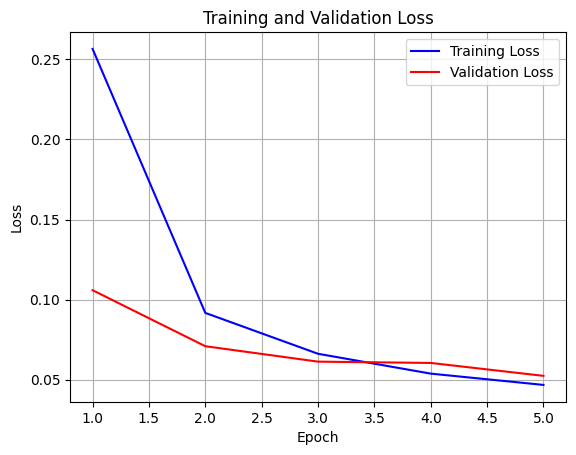

In [44]:
import matplotlib.pyplot as plt
batch_size=64
epochs=5
train_data_original=datasets.MNIST(root='./data',train=True,download=True,transform=transforms.ToTensor())
test_data_original=datasets.MNIST(root='./data',train=False,download=True,transform=transforms.ToTensor())
train_loader_original=DataLoader(train_data_original,batch_size=batch_size,shuffle=True)
test_loader_original=DataLoader(test_data_original,batch_size=batch_size,shuffle=False)
model=SimpleCNN()
accuracy_original,training_loss_original,validation_loss_original=training_fun(model,train_loader_original,test_loader_original,epochs=epochs)
print(f"Accuratezza MNIST Originale: {accuracy_original}%")
plt.plot(np.arange(1,epochs+1),training_loss_original,label='Training Loss',color="blue")
plt.plot(np.arange(1,epochs+1),validation_loss_original,label='Validation Loss',color="red")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.legend()
plt.show()



Nele secondo caso abbiamo un training loss che scende in maniera regolare e un validation loss che tra la seconda e la quarta epoca sale e designa all'inizio un overfitting. Questo è dato soprattutto dalla binarizzazione delle immagini: eliminando le scale di grigio si semplifica l'addestramento della rete ma si perde dei dettagli informativi rendendo la generalizzazione più difficile, infatti anche l'accuratezza ne ha risentito leggermente

Accuratezza MNIST Binarizzato: 98.0%


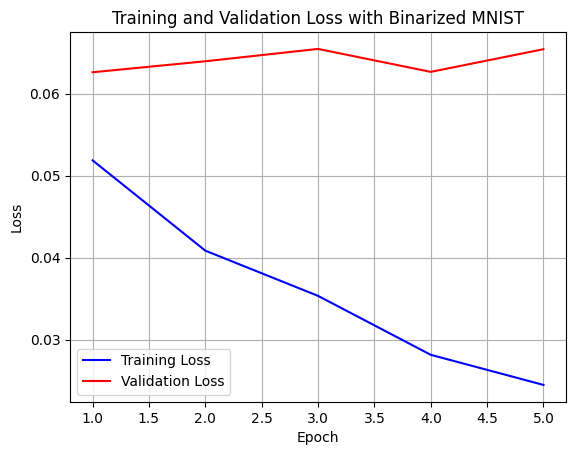

In [45]:
train_loader_binarized=DataLoader(train_data_binarized,batch_size=batch_size,shuffle=True)
test_loader_binarized=DataLoader(test_data_binarized,batch_size=batch_size,shuffle=False)
accuracy_binarized,training_loss_binarized,validation_loss_binarized=training_fun(model,train_loader_binarized,test_loader_binarized,epochs=epochs)
print(f"Accuratezza MNIST Binarizzato: {accuracy_binarized}%")
plt.plot(np.arange(1,epochs+1),training_loss_binarized,label='Training Loss',color="blue")
plt.plot(np.arange(1,epochs+1),validation_loss_binarized,label='Validation Loss',color="red")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss with Binarized MNIST')
plt.grid(True)
plt.legend()
plt.show()

Nel terzo e ultimo caso si nota come il criterio della Maximum Information non ha causato una perdita significativa di informazioni utile. L'andamento grafico del training e del validation loss è molto simile al primo caso e dimostra che la scelta di feature significative non influisce troppo negativamente sull'accuratezza del classificatore

Accuratezza MNIST con feature detector: 97.88%


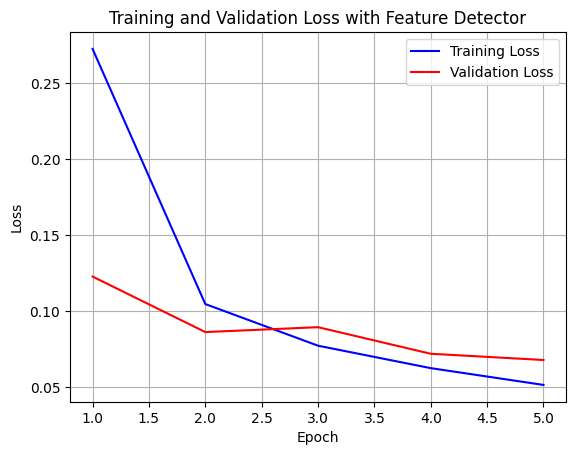

In [46]:
class FeatureClassifier(torch.nn.Module):
  def __init__(self,feature_detector,K):
    super().__init__()
    self.feature_detector=feature_detector
    for param in self.feature_detector.parameters():
          param.requires_grad = False
    self.cnn=SimpleCNN(in_channels=K, input_spatial_size=26)

  def forward(self,x):
    with torch.no_grad():
        features = self.feature_detector(x)
    return self.cnn(features)

K=len(selected_indices)
model_feat=FeatureClassifier(real_feature_detector,K)
accuracy_feat, training_loss_feat, validation_loss_feat = training_fun(model_feat,train_loader_binarized,test_loader_binarized)
print(f"Accuratezza MNIST con feature detector: {accuracy_feat}%")
plt.plot(np.arange(1,epochs+1),training_loss_feat,label='Training Loss',color="blue")
plt.plot(np.arange(1,epochs+1),validation_loss_feat,label='Validation Loss',color="red")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss with Feature Detector')
plt.grid(True)
plt.legend()
plt.show()